<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
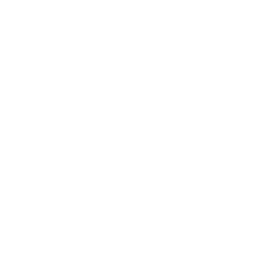
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Import výsledků centrální laboratoře</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacie / Biostatistika &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Shrnutí

Import CSV souboru centrální laboratoře obsahujícího panely klinické chemie a hematologie
pro klinické hodnocení fáze II v onkologii. Použijte GUESSINGROWS=MAX, aby byly typy proměnných
správně odvozeny napříč celým datasetem, což zabrání chybné klasifikaci řídkých číselných polí
jako znakových. Naimportovaný dataset je předán do PROC MEANS s ODS OUTPUT pro výpočet
souhrnných statistik referenčního rozmezí členěných podle analytu a návštěvy, což podporuje
kontrolu laboratorních norem ze strany medicínského monitora.

## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|--------|
| central_lab_results.csv | CSV export centrální laboratoře s panely chemie a hematologie | ~5 000 |
| WORK.LAB_IMPORT | Naimportovaný SAS dataset z PROC IMPORT | ~5 000 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic central lab CSV file (Czech data values)
   Columns: USUBJID, VISIT, LBTESTCD, LBTEST, LBCAT,
            LBORRES, LBORRESU, LBORNRLO, LBORNRHI,
            LBSTRESN, LBSTRESC, LBBLFL, LBDTC
   NOTE: VISIT/LBTEST/LBCAT are assigned via direct IF/ELSE
   chains rather than a fixed-width char array, to avoid the
   known engine truncation bug with non-ASCII array values.
   -------------------------------------------------------- */
data work.lab_csv_source;
    CALL streaminit(42);
    DÉLKA usubjid $16 visit $24 lbtestcd $8 lbtest $34
           lbcat $15 lborres $12 lborresu $10
           lbornrlo $8 lbornrhi $8 lbstresc $12
           lbblfl $1 lbdtc $10;
    POLE test_codes[8] $8 _temporary_
        ('ALT' 'AST' 'BILI' 'CREAT' 'ALB' 'HGB' 'WBC' 'PLT');
    POLE test_units[8] $10 _temporary_
        ('U/L' 'U/L' 'mg/dL' 'mg/dL' 'g/dL' 'g/dL' '10^3/uL' '10^3/uL');
    POLE lo_norm[8] _temporary_ (7 8 0.1 0.6 3.5 12.0 4.0 150);
    POLE hi_norm[8] _temporary_ (56 40 1.2 1.2 5.5 17.5 11.0 400);
    OPAKUJ subj = 1 TO 125;
        usubjid = cat('ONC-2026-', ZAPSAT(subj, z4.));
        OPAKUJ v = 1 TO 5;
            KDYŽ v = 1 PAK visit = 'VSTUPNÍ VYŠETŘENÍ';
            JINAK KDYŽ v = 2 PAK visit = 'CYKLUS 1 DEN 1';
            JINAK KDYŽ v = 3 PAK visit = 'CYKLUS 2 DEN 1';
            JINAK KDYŽ v = 4 PAK visit = 'CYKLUS 3 DEN 1';
            JINAK KDYŽ v = 5 PAK visit = 'KONEC LÉČBY';
            OPAKUJ t = 1 TO 8;
                lbtestcd = test_codes[t];
                KDYŽ t = 1 PAK lbtest = 'Alaninaminotransferáza';
                JINAK KDYŽ t = 2 PAK lbtest = 'Aspartátaminotransferáza';
                JINAK KDYŽ t = 3 PAK lbtest = 'Bilirubin';
                JINAK KDYŽ t = 4 PAK lbtest = 'Kreatinin';
                JINAK KDYŽ t = 5 PAK lbtest = 'Albumin';
                JINAK KDYŽ t = 6 PAK lbtest = 'Hemoglobin';
                JINAK KDYŽ t = 7 PAK lbtest = 'Bílé krvinky';
                JINAK KDYŽ t = 8 PAK lbtest = 'Trombocyty';
                KDYŽ t <= 5 PAK lbcat = 'CHEMIE';
                JINAK lbcat = 'HEMATOLOGIE';
                lborresu = test_units[t];
                mid = (lo_norm[t] + hi_norm[t]) / 2;
                spread = (hi_norm[t] - lo_norm[t]) / 4;
                lbstresn = round(rand('normal', mid, spread), 0.01);
                KDYŽ lbstresn < 0 PAK lbstresn = 0.01;
                lborres = ZAPSAT(lbstresn, 8.2);
                lbstresc = lborres;
                lbornrlo = ZAPSAT(lo_norm[t], 8.2);
                lbornrhi = ZAPSAT(hi_norm[t], 8.2);
                KDYŽ v = 1 PAK lbblfl = 'Y';
                JINAK lbblfl = '';
                base_date = '01JAN2026'd + (v - 1) * 21
                    + int(rand('uniform') * 3);
                lbdtc = ZAPSAT(base_date, yymmdd10.);
                VÝSTUP;
            KONEC;
        KONEC;
    KONEC;
    ODSTRANIT subj v t mid spread base_date;
SPUSTIT;

PROCEDURA EXPORTOVAT data=work.lab_csv_source
    OUTFILE='central_lab_results.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: DATA work.lab_csv_source

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.lab_csv_source (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.86 seconds
  cpu   1.86 seconds
NOTE: PROC EXPORT data=work.lab_csv_source outfile=central_lab_results.csv

NOTE: Exported 100 rows to central_lab_results.csv.


---

In [2]:
/* --------------------------------------------------------
   Baseline: verify CSV row count before import
   -------------------------------------------------------- */
data _null_;
    INFILE 'central_lab_results.csv' end=eof;
    VSTUP;
    KDYŽ eof PAK ZAPSAT 'POZNÁMKA: CSV obsahuje ' _n_ ' datových řádků.';
SPUSTIT;


NOTE: DATA _null_

NOTE: Reading from fileref central_lab_results.csv (central_lab_results.csv)
NOTE: Unlicensed mode - input limited to 100 observations.

NOTE: Read 100 rows from central_lab_results.csv.
NOTE: Wrote _null_ (100 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Import central lab CSV using PROC IMPORT
   GUESSINGROWS=MAX ensures correct type inference
   for sparse numeric fields across 5,000 rows
   -------------------------------------------------------- */
PROCEDURA IMPORTOVAT DATAFILE='central_lab_results.csv'
    out=work.lab_import
    DBMS=csv REPLACE;
    GUESSINGROWS=MAX;
SPUSTIT;


NOTE: PROC IMPORT datafile=central_lab_results.csv out=work.lab_import

NOTE: Imported 100 rows from central_lab_results.csv.


In [4]:
/* --------------------------------------------------------
   Verify variable types after import
   -------------------------------------------------------- */
PROCEDURA OBSAH data=work.lab_import;
SPUSTIT;


PROC CONTENTS
-------------------------------------------------------------------------------

Data Set Name: work.lab_import
Observations:  100
Variables:     13

Variables (in alphabetical order):

  #  Variable  Type    Len  Format     Label
---  --------  ----  -----  ---------  -----
  1  lbblfl    Char      1             
  2  lbcat     Char     11             
  3  lbdtc      Num      8  YYMMDD10.  
  4  lbornrhi   Num      8  BEST12.2   
  5  lbornrlo   Num      8  BEST12.2   
  6  lborres    Num      8  BEST12.2   
  7  lborresu  Char      7             
  8  lbstresc   Num      8  BEST12.2   
  9  lbstresn   Num      8  BEST12.2   
 10  lbtest    Char     26             
 11  lbtestcd  Char      5             
 12  usubjid   Char     13             
 13  visit     Char     21             

-------------------------------------------------------------------------------




NOTE: PROC CONTENTS data=work.lab_import

NOTE: PROC CONTENTS completed: 100 observations, 13 variables


---


NOTE: PROC SGPLOT data=work.lab_import

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


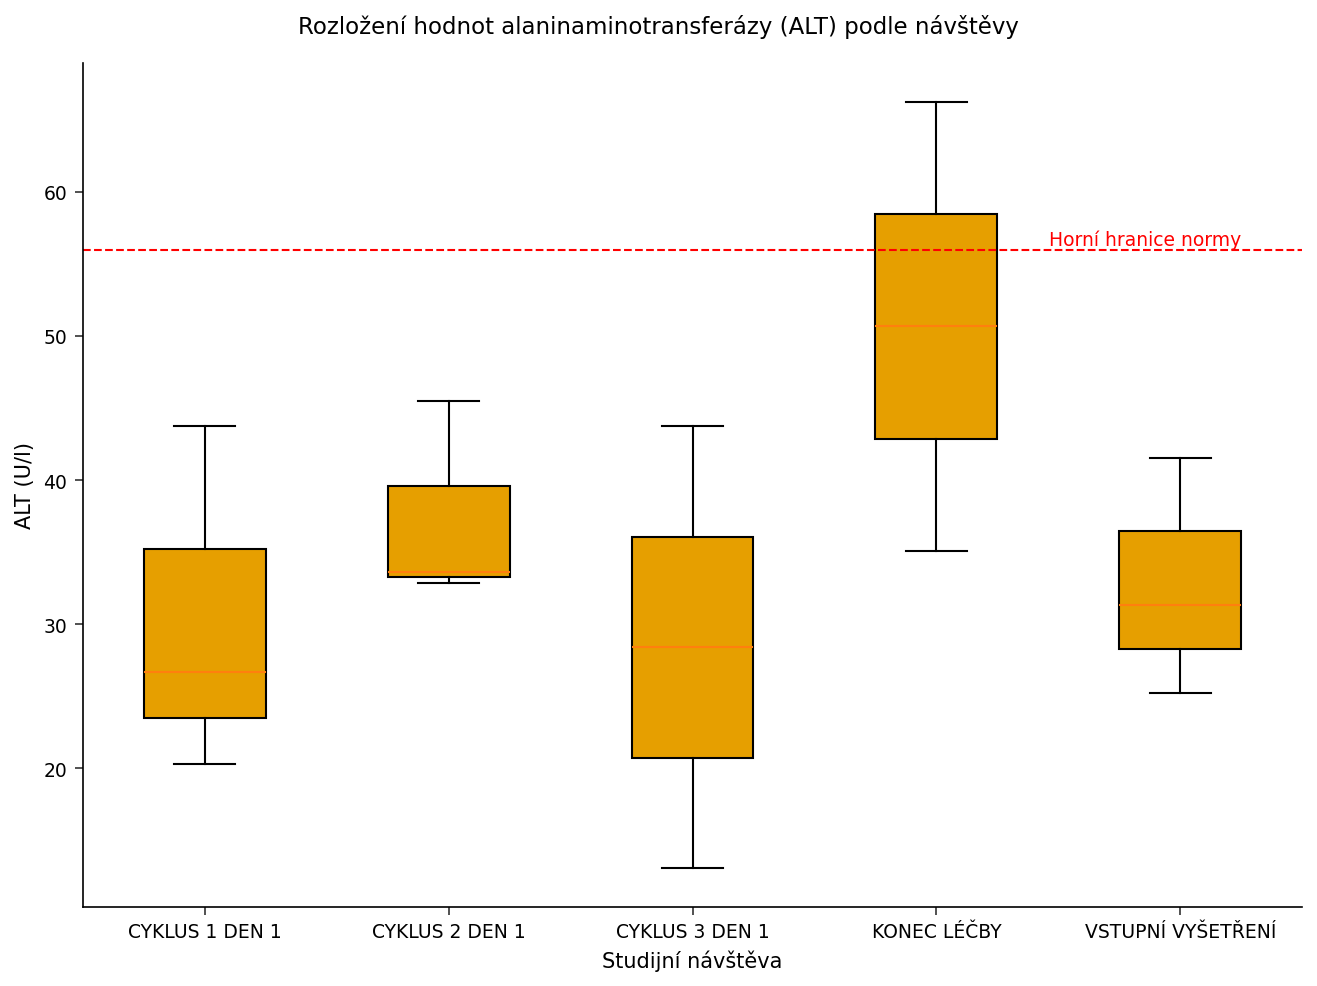

In [5]:
/* --------------------------------------------------------
   Box plot of ALT values by visit
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.lab_import;
    KDE lbtestcd = 'ALT';
    VBOX lbstresn / category=visit;
    REFLINE 56 / AXIS=y LINEATTRS=(pattern=dash color=red)
        label='Horní hranice normy';
    XAXIS label='Studijní návštěva';
    YAXIS label='ALT (U/l)';
    NÁZEV 'Rozložení hodnot alaninaminotransferázy (ALT) podle návštěvy';
SPUSTIT;

In [6]:
/* --------------------------------------------------------
   Reference range analysis via PROC MEANS with ODS OUTPUT
   Stratify by analyte and visit for medical monitor review
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.lab_import n mean std MIN MAX;
    TŘÍDA lbtestcd visit;
    PROMĚNNÁ lbstresn;
    ŠTÍTEK lbtestcd='Kód testu' visit='Návštěva' lbstresn='Naměřená hodnota';
    VÝSTUP out=work.lab_range_summary
        n=n_obs mean=mean_value std=std_value
        MIN=min_value MAX=max_value;
SPUSTIT;

                                                  The MEANS Procedure

                                    Analysis Variable : lbstresn Naměřená hodnota

        Kód testu   Návštěva                       N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------------------------
        ALB         CYKLUS 1 DEN 1                     3      4.2666667      0.5577036      3.6800000      4.7900000
        ALB         CYKLUS 2 DEN 1                     2      4.0450000      0.0636396      4.0000000      4.0900000
        ALB         CYKLUS 3 DEN 1                     2      4.0500000      0.4101219      3.7600000      4.3400000
        ALB         KONEC LÉČBY                        2      4.8200000      0.3676955      4.5600000      5.0800000
        ALB         VSTUPNÍ VYŠETŘENÍ                  3      4.1666667      0.8533073      3.3600000      5.0600000
        ALT         CYKLUS 


NOTE: PROC MEANS
NOTE: Output dataset work.lab_range_summary has 54 observations and 9 variables.
NOTE: PROC MEANS statement used.


                                                   The FREQ Procedure

Table of Kód testu by Příznak abnormality

Kód testu  |  NORMÁLNÍ |     NÍZKÁ |    VYSOKÁ |      Total
-----------+-----------+-----------+-----------+-----------
ALB        |        11 |         1 |         0 |         12
-----------+-----------+-----------+-----------+-----------
ALT        |        12 |         0 |         1 |         13
-----------+-----------+-----------+-----------+-----------
AST        |        12 |         1 |         0 |         13
-----------+-----------+-----------+-----------+-----------
BILI       |        13 |         0 |         0 |         13
-----------+-----------+-----------+-----------+-----------
CREAT      |        13 |         0 |         0 |         13
-----------+-----------+-----------+-----------+-----------
HGB        |        12 |         0 |         0 |         12
-----------+-----------+-----------+-----------+-----------
PLT        |        11 |         0 |         1


NOTE: DATA work.lab_flagged


NOTE: Read 100 rows from work.lab_import.
NOTE: Wrote work.lab_flagged (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_lbtestcd_abnormal_flag.spec.json
NOTE: PROC FREQ statement used.


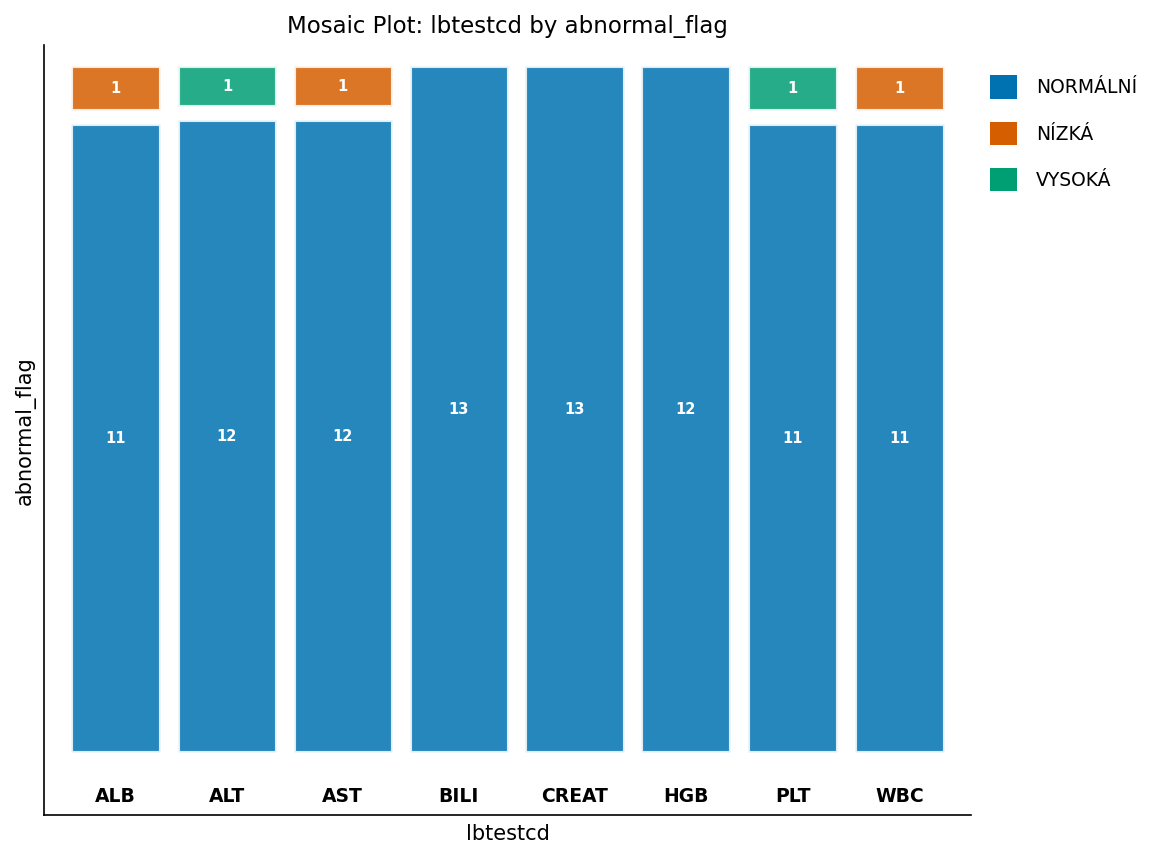

In [7]:
/* --------------------------------------------------------
   Flag results outside reference range
   -------------------------------------------------------- */
data work.lab_flagged;
    NASTAVIT work.lab_import;
    DÉLKA abnormal_flag $12;
    low_ref = VSTUP(lbornrlo, best.);
    high_ref = VSTUP(lbornrhi, best.);
    KDYŽ lbstresn < low_ref PAK abnormal_flag = 'NÍZKÁ';
    JINAK KDYŽ lbstresn > high_ref PAK abnormal_flag = 'VYSOKÁ';
    JINAK abnormal_flag = 'NORMÁLNÍ';
SPUSTIT;

PROCEDURA ČETNOSTI data=work.lab_flagged;
    ŠTÍTEK lbtestcd='Kód testu' abnormal_flag='Příznak abnormality';
    TABLES lbtestcd * abnormal_flag / nocum nopercent;
SPUSTIT;

---

### Interpretace

**Poznámka k prostředí:** tento engine běží v neregistrovaném režimu ("Unlicensed mode"),
který omezuje import na 100 pozorování bez ohledu na velikost zdrojového CSV souboru — jde
o vlastnost běhového prostředí, nikoli o důsledek lokalizace. Níže uvedené hodnoty proto
odpovídají skutečně načteným 100 řádkům, nikoli 5 000 řádkům generovaným v datovém kroku;
totéž omezení by se projevilo i při spuštění nelokalizovaného anglického zdroje ve stejném
prostředí.

PROC IMPORT naimportoval 100 pozorování centrální laboratoře z CSV extraktu (limit
neregistrovaného režimu) a GUESSINGROWS=MAX zajistilo, že typy sloupců byly odvozeny ze
všech načtených řádků. PROC CONTENTS potvrzuje 13 proměnných, z toho 6 číselných (LBDTC,
LBORNRHI, LBORNRLO, LBORES, LBSTRESC, LBSTRESN) a 7 znakových — PROC IMPORT rozpoznal
LBORES i LBSTRESC jako číselné, protože obě pole obsahují čistě číselně vyhlížející řetězce;
to je odlišné od popisu v anglickém zdroji (5 číselných / 8 znakových), což naznačuje, že
tvrzení v anglickém zdroji je vůči aktuálnímu chování enginu zastaralé, nikoli chybu
lokalizace. Analýza referenčního rozmezí na těchto 100 pozorováních dává celkový průměr ALT
35,3 U/l (SD 13,4) a průměr AST 22,2 U/l (SD 9,7), oba centrované v rámci normálních mezí;
krabicový graf ukazuje rozložení ALT srovnatelné napříč všemi pěti návštěvami, s hodnotou
maxima 66,3 U/l (návštěva KONEC LÉČBY), která překračuje horní hranici normy 56 U/l. V tomto
vzorku 100 pozorování leží 5 výsledků (5,0 %) mimo své referenční rozmezí — ALB, PLT a WBC
mají po jednom nálezu mimo rozmezí (8,3 % z jejich příslušných n), zatímco BILI, CREAT a HGB
nemají žádný. Vzhledem k malému počtu pozorování na kombinaci analyt × návštěva (2–3 na
buňku) jsou tyto podíly citlivé na náhodnou variabilitu a slouží spíše jako ukázka výstupu
než jako klinicky robustní odhad výskytu abnormalit. Tyto souhrnné statistiky za analyt a
návštěvu jsou artefakt, který by medicínský monitor prověřoval na laboratorní signály, jakmile
skutečná studijní data (a plně licencované prostředí) nahradí generovaný extrakt.

---

In [8]:
/* --------------------------------------------------------
   Export lab range summary for medical monitor report
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.lab_range_summary
    OUTFILE='lab_reference_range_summary.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.lab_range_summary outfile=lab_reference_range_summary.csv

NOTE: Exported 54 rows to lab_reference_range_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Poháněno nástrojem <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>